# **Dimensionality Reduction on MNIST Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
import seaborn as sns
import cupy as cp
from itertools import product

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
import plotly.express as px
from sklearn.decomposition import PCA
import xgboost as xgb

from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
## Stacking Models using DESLIB

# # Train a pool of 10 classifiers
# pool_classifiers = RandomForestClassifier(n_estimators=10)
# pool_classifiers.fit(X_train, y_train)

# # Initialize the DES model
# knorae = KNORAE(pool_classifiers)

# # Preprocess the Dynamic Selection dataset (DSEL)
# knorae.fit(X_dsel, y_dsel)

# # Predict new examples:
# knorae.predict(X_test)


In [2]:
print(xgb.build_info())


{'BUILTIN_PREFETCH_PRESENT': True, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'GCC_VERSION': [10, 3, 1], 'GLIBC_VERSION': [2, 28], 'MM_PREFETCH_PRESENT': True, 'NCCL_VERSION': [2, 29, 2], 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': True, 'USE_FEDERATED': True, 'USE_NCCL': True, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': '/usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so'}


In [3]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False,
    parser="pandas"
)

y = y.astype(int)

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Make labels clean integer arrays
y_train = np.asarray(y_train, dtype=np.int32)
y_val = np.asarray(y_val, dtype=np.int32)
y_test = np.asarray(y_test, dtype=np.int32)
y_train_full = np.asarray(y_train_full, dtype=np.int32)

Train: (44800, 784)
Validation: (11200, 784)
Test: (14000, 784)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_full_scaled = scaler.transform(X_train_full)

In [6]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
best_n_components = np.argmax(cum_var >= 0.95) + 1

print(f"95% Variance Retained at {best_n_components} Components")

n_components = min(best_n_components + 6, X_train_scaled.shape[1])
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Shape:", X_train_scaled.shape)
print("Reduced Shape :", X_train_pca.shape)


95% Variance Retained at 324 Components
Original Shape: (44800, 784)
Reduced Shape : (44800, 330)


In [8]:
X_train_gpu = cp.asarray(X_train_pca.astype(np.float32))
X_val_gpu = cp.asarray(X_val_pca.astype(np.float32))
X_test_gpu = cp.asarray(X_test_pca.astype(np.float32))

y_train_gpu = cp.asarray(y_train)
y_val_gpu = cp.asarray(y_val)
y_test_gpu = cp.asarray(y_test)

dtrain = xgb.DMatrix(X_train_gpu, label=y_train_gpu)
dval = xgb.DMatrix(X_val_gpu, label=y_val_gpu)
dtest = xgb.DMatrix(X_test_gpu, label=y_test_gpu)


In [9]:
param_grid = {
    "max_depth": [4, 6, 8],
    "eta": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

num_class = len(np.unique(y_train))

base_params = {
    "objective": "multi:softprob",
    "num_class": num_class,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "device": "cuda",
    "seed": 42,
    "verbosity": 0,
}

best_score = -1.0
best_params = None
best_num_boost_round = None
best_booster = None

for md, eta, ss, cs in product(
    param_grid["max_depth"],
    param_grid["eta"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
):
    params = base_params.copy()
    params.update({
        "max_depth": md,
        "eta": eta,
        "subsample": ss,
        "colsample_bytree": cs,
    })

    booster = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=500,
        evals=[(dval, "val")],
        early_stopping_rounds=20,
        verbose_eval=False
    )

    val_proba = booster.predict(dval)
    val_pred = np.argmax(val_proba, axis=1)
    score = accuracy_score(y_val, val_pred)

    print(f"md={md}, eta={eta}, ss={ss}, cs={cs} -> {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = {
            "max_depth": md,
            "eta": eta,
            "subsample": ss,
            "colsample_bytree": cs,
        }
        best_num_boost_round = booster.best_iteration + 1
        best_booster = booster

print("\nBest Params:", best_params)
print("Best Validation Accuracy:", best_score)
print("Best Boost Rounds:", best_num_boost_round)

md=4, eta=0.05, ss=0.8, cs=0.8 -> 0.9535
md=4, eta=0.05, ss=0.8, cs=1.0 -> 0.9527
md=4, eta=0.05, ss=1.0, cs=0.8 -> 0.9501
md=4, eta=0.05, ss=1.0, cs=1.0 -> 0.9502
md=4, eta=0.1, ss=0.8, cs=0.8 -> 0.9606
md=4, eta=0.1, ss=0.8, cs=1.0 -> 0.9601
md=4, eta=0.1, ss=1.0, cs=0.8 -> 0.9596
md=4, eta=0.1, ss=1.0, cs=1.0 -> 0.9593
md=6, eta=0.05, ss=0.8, cs=0.8 -> 0.9608
md=6, eta=0.05, ss=0.8, cs=1.0 -> 0.9593
md=6, eta=0.05, ss=1.0, cs=0.8 -> 0.9604
md=6, eta=0.05, ss=1.0, cs=1.0 -> 0.9589
md=6, eta=0.1, ss=0.8, cs=0.8 -> 0.9627
md=6, eta=0.1, ss=0.8, cs=1.0 -> 0.9613
md=6, eta=0.1, ss=1.0, cs=0.8 -> 0.9628
md=6, eta=0.1, ss=1.0, cs=1.0 -> 0.9611
md=8, eta=0.05, ss=0.8, cs=0.8 -> 0.9605
md=8, eta=0.05, ss=0.8, cs=1.0 -> 0.9597
md=8, eta=0.05, ss=1.0, cs=0.8 -> 0.9581
md=8, eta=0.05, ss=1.0, cs=1.0 -> 0.9569
md=8, eta=0.1, ss=0.8, cs=0.8 -> 0.9621
md=8, eta=0.1, ss=0.8, cs=1.0 -> 0.9599
md=8, eta=0.1, ss=1.0, cs=0.8 -> 0.9616
md=8, eta=0.1, ss=1.0, cs=1.0 -> 0.9591

Best Params: {'max_depth': 

In [10]:
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

pca_final = PCA(n_components=n_components)
X_train_full_pca = pca_final.fit_transform(X_train_full_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

X_train_full_gpu = cp.asarray(X_train_full_pca.astype(np.float32))
X_test_gpu_final = cp.asarray(X_test_pca_final.astype(np.float32))

y_train_full_gpu = cp.asarray(y_train_full)
y_test_gpu_final = cp.asarray(y_test)

dtrain_full = xgb.DMatrix(X_train_full_gpu, label=y_train_full_gpu)
dtest_full = xgb.DMatrix(X_test_gpu_final, label=y_test_gpu_final)

final_params = base_params.copy()
final_params.update(best_params)

final_booster = xgb.train(
    params=final_params,
    dtrain=dtrain_full,
    num_boost_round=best_num_boost_round,
    verbose_eval=False
)

In [11]:
test_proba = final_booster.predict(dtest_full)
y_pred = np.argmax(test_proba, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9631428571428572

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.99      0.98      0.99      1575
           2       0.96      0.96      0.96      1398
           3       0.95      0.95      0.95      1428
           4       0.97      0.96      0.96      1365
           5       0.96      0.94      0.95      1263
           6       0.97      0.98      0.98      1375
           7       0.96      0.97      0.96      1459
           8       0.94      0.95      0.95      1365
           9       0.95      0.94      0.95      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



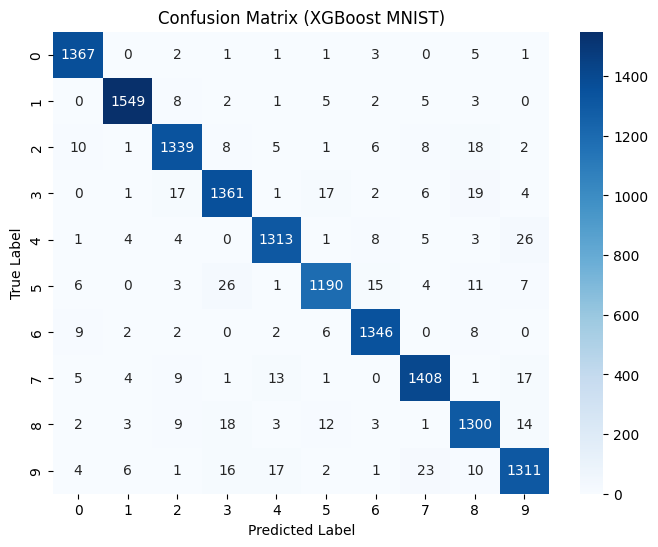

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (XGBoost MNIST)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()